In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv(r"C:\Users\DIYA\OneDrive\Desktop\analysis\dataset.csv")

In [8]:
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,M,65,1,1,1,2,2,1,2,2,2,2,2,2,1,NO
1,F,55,1,2,2,1,1,2,2,2,1,1,1,2,2,NO
2,F,78,2,2,1,1,1,2,1,2,1,1,2,1,1,YES
3,M,60,2,1,1,1,2,1,2,1,1,2,1,2,2,YES
4,F,80,1,1,2,1,1,2,1,2,1,1,1,1,2,NO


In [9]:
df.shape

(3000, 16)

In [10]:
df.columns

Index(['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC_DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING',
       'ALCOHOL_CONSUMING', 'COUGHING', 'SHORTNESS_OF_BREATH',
       'SWALLOWING_DIFFICULTY', 'CHEST_PAIN', 'LUNG_CANCER'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 3000 non-null   object
 1   AGE                    3000 non-null   int64 
 2   SMOKING                3000 non-null   int64 
 3   YELLOW_FINGERS         3000 non-null   int64 
 4   ANXIETY                3000 non-null   int64 
 5   PEER_PRESSURE          3000 non-null   int64 
 6   CHRONIC_DISEASE        3000 non-null   int64 
 7   FATIGUE                3000 non-null   int64 
 8   ALLERGY                3000 non-null   int64 
 9   WHEEZING               3000 non-null   int64 
 10  ALCOHOL_CONSUMING      3000 non-null   int64 
 11  COUGHING               3000 non-null   int64 
 12  SHORTNESS_OF_BREATH    3000 non-null   int64 
 13  SWALLOWING_DIFFICULTY  3000 non-null   int64 
 14  CHEST_PAIN             3000 non-null   int64 
 15  LUNG_CANCER          

In [12]:
df.isnull().sum()

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC_DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL_CONSUMING        0
COUGHING                 0
SHORTNESS_OF_BREATH      0
SWALLOWING_DIFFICULTY    0
CHEST_PAIN               0
LUNG_CANCER              0
dtype: int64

In [13]:
df.nunique()

GENDER                    2
AGE                      51
SMOKING                   2
YELLOW_FINGERS            2
ANXIETY                   2
PEER_PRESSURE             2
CHRONIC_DISEASE           2
FATIGUE                   2
ALLERGY                   2
WHEEZING                  2
ALCOHOL_CONSUMING         2
COUGHING                  2
SHORTNESS_OF_BREATH       2
SWALLOWING_DIFFICULTY     2
CHEST_PAIN                2
LUNG_CANCER               2
dtype: int64

In [14]:
df['SMOKING'].value_counts()

SMOKING
1    1527
2    1473
Name: count, dtype: int64

In [15]:
df['GENDER'].value_counts()

GENDER
M    1514
F    1486
Name: count, dtype: int64

In [16]:
df['AGE'].describe()

count    3000.000000
mean       55.169000
std        14.723746
min        30.000000
25%        42.000000
50%        55.000000
75%        68.000000
max        80.000000
Name: AGE, dtype: float64

In [17]:
df['AGE'].mode()

0    54
Name: AGE, dtype: int64

In [18]:
df.duplicated().sum()

np.int64(2)

In [19]:
df = df.drop_duplicates()

In [20]:
df.shape

(2998, 16)

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df['LUNG_CANCER'].value_counts()

LUNG_CANCER
YES    1517
NO     1481
Name: count, dtype: int64

In [23]:
df['SMOKING'].value_counts()

SMOKING
1    1525
2    1473
Name: count, dtype: int64

In [24]:
df.select_dtypes(include='object').apply(pd.Series.value_counts)

,GENDER,LUNG_CANCER
F,1486.0,NaN
M,1512.0,NaN
NO,NaN,1481.0
YES,NaN,1517.0


In [25]:
id_cols = df.columns[2:-1]
df[id_cols].nunique()

SMOKING                  2
YELLOW_FINGERS           2
ANXIETY                  2
PEER_PRESSURE            2
CHRONIC_DISEASE          2
FATIGUE                  2
ALLERGY                  2
WHEEZING                 2
ALCOHOL_CONSUMING        2
COUGHING                 2
SHORTNESS_OF_BREATH      2
SWALLOWING_DIFFICULTY    2
CHEST_PAIN               2
dtype: int64

In [26]:
Q1 = df['AGE'].quantile(0.25)
Q3 = df['AGE'].quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 42.0
Q3: 68.0
IQR: 26.0


In [27]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: 3.0
Upper Limit: 107.0


In [28]:
outliers = df[(df['AGE'] < lower_limit) | (df['AGE'] > upper_limit)]

print("Number of outliers:", len(outliers))

Number of outliers: 0


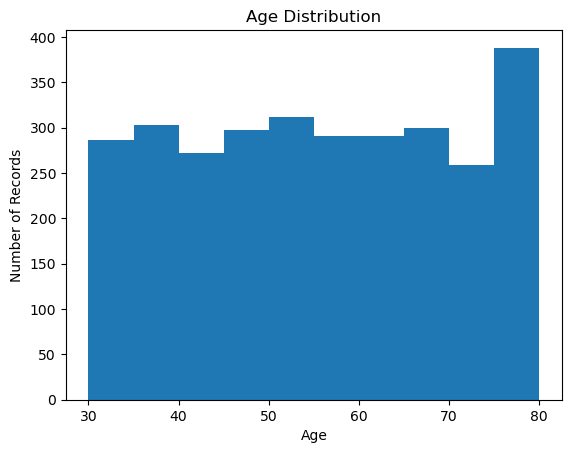

In [29]:
plt.hist(df['AGE'], bins=10)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Records')
plt.show()

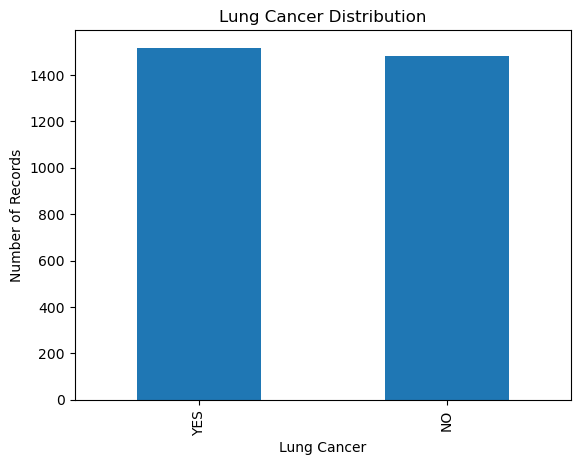

In [30]:
df['LUNG_CANCER'].value_counts().plot(kind='bar')

plt.title('Lung Cancer Distribution')
plt.xlabel('Lung Cancer')
plt.ylabel('Number of Records')
plt.show()

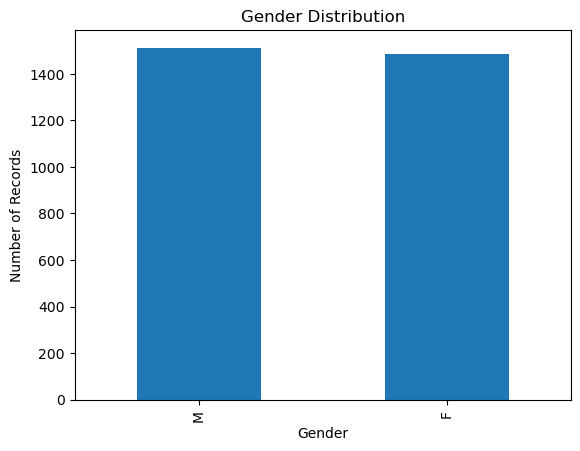

In [31]:
df['GENDER'].value_counts().plot(kind='bar')

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Records')
plt.show()

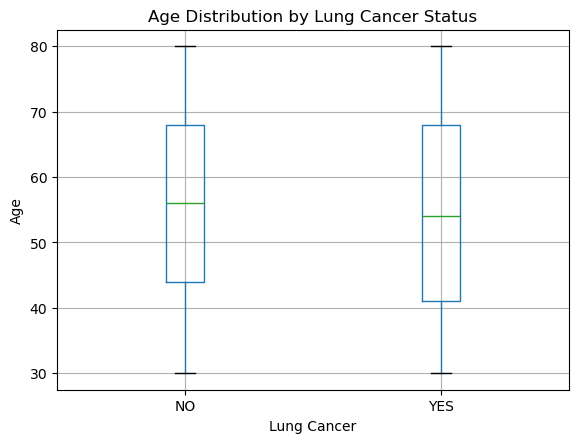

In [32]:
df.boxplot(column='AGE', by='LUNG_CANCER')

plt.title('Age Distribution by Lung Cancer Status')
plt.suptitle('')
plt.xlabel('Lung Cancer')
plt.ylabel('Age')
plt.show()

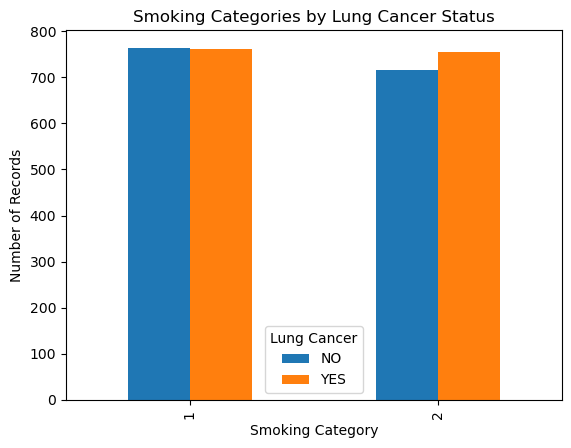

In [33]:
pd.crosstab(df['SMOKING'], df['LUNG_CANCER']).plot(kind='bar')

plt.title('Smoking Categories by Lung Cancer Status')
plt.xlabel('Smoking Category')
plt.ylabel('Number of Records')
plt.legend(title='Lung Cancer')
plt.show()

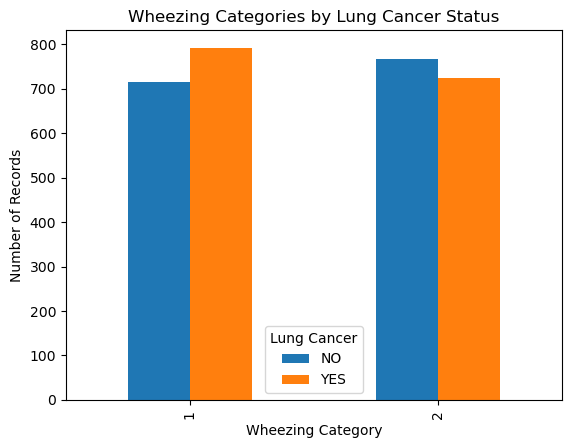

In [34]:
pd.crosstab(df['WHEEZING'], df['LUNG_CANCER']).plot(kind='bar')

plt.title('Wheezing Categories by Lung Cancer Status')
plt.xlabel('Wheezing Category')
plt.ylabel('Number of Records')
plt.legend(title='Lung Cancer')
plt.show()